# Notebook 1 — Data Profiling & Cleaning
**Pharma Supplier Sales — Multi-Warehouse Dataset**

Goal: produce a trusted, cleaned transaction table and a Data Quality (QA) report **before** any entity resolution or analytics.

Pipeline position: `Raw CSV → [THIS NOTEBOOK] → clean_sales.csv → Notebook 2 (Entity Resolution)`

Cleaning decisions applied here (each justified inline):
1. Drop geography columns (`city`, `region`, `area`, `area_id`) — 100% null, confirmed by stakeholder to remove.
2. Drop `created_at` — it is the warehouse *export* timestamp (all values Apr–Jun 2026), not a business event.
3. Parse `creation_date`; quarantine corrupted values (`0000-00-00`).
4. Remove non-transactions (quantity = 0 **and** amount = 0).
5. Normalize whitespace in all text columns.
6. Build `rep_name_raw` = `employee_name`, falling back to `user_name` when null (flagged).
7. Flag (not delete) statistical outliers — large orders are plausible in B2B pharma distribution.


In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

RAW_PATH = 'data.csv'   # supplier_sales_20260604_222403.csv
df = pd.read_csv(RAW_PATH)
print(f"Raw shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Raw shape: 10,000 rows x 20 columns


,id,supplier_id,invoice_id,prod_id,product_name,quantity,discount,total_amount,account_id,account_name,account_address,user_id,user_name,employee_name,city,region,area,area_id,creation_date,created_at
0,48652728,59,32259,7,سيبروسين مرهم س--ج,10,15.0,178.50,637,ص مها مديرية امن الجيزة &ش*& 003,كوبرى الجلاء ميدان فينى الدقى,6,نهى الدالى,نهى الدالى,NaN,NaN,NaN,NaN,2025-05-25 13:43:10,2026-05-19 16:29:03
1,48652935,59,32281,7,سيبروسين مرهم س--ج,3,15.0,53.55,4365,ص السعدنى فيصل 002,شارع مصرف جلال خلف فندق قاعود بجوار مسجد,6,نهى الدالى,نهى الدالى,NaN,NaN,NaN,NaN,2025-05-25 14:35:04,2026-05-19 16:29:03
2,48653089,59,32301,7,سيبروسين مرهم س--ج,2,21.0,33.18,3297,ص منى احمد امبابه نقدى 004,شارع جمال عبد الناصر امام مدرسه تبارك الخاصه,137,اسماء رجب,اسماء رجب,NaN,NaN,NaN,NaN,2025-05-25 15:21:21,2026-05-19 16:29:03


## 1. Profiling — what are we dealing with?
Per-column nulls, cardinality, and per-supplier coverage. The dataset is **10 suppliers x 1,000 rows each** — a stratified sample, which matters later for cross-supplier comparisons.

In [2]:
profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulls': df.isna().sum(),
    'null_%': (df.isna().mean() * 100).round(1),
    'unique': df.nunique(),
})
profile

,dtype,nulls,null_%,unique
id,int64,0,0.0,10000
supplier_id,int64,0,0.0,10
invoice_id,int64,0,0.0,2937
prod_id,int64,0,0.0,4776
product_name,str,0,0.0,5067
quantity,int64,0,0.0,60
discount,float64,0,0.0,87
total_amount,float64,0,0.0,3926
account_id,int64,0,0.0,1053
account_name,str,0,0.0,1104


In [3]:
# Per-supplier temporal coverage — critical finding
dates = pd.to_datetime(df['creation_date'], errors='coerce')
coverage = (df.assign(date=dates)
              .groupby('supplier_id')['date']
              .agg(first_tx='min', last_tx='max', rows='count'))
coverage['span_days'] = (coverage['last_tx'] - coverage['first_tx']).dt.days
coverage

,first_tx,last_tx,rows,span_days
supplier_id,,,,
59,2025-01-02 16:16:02,2026-06-04 11:12:03,1000,517
60,2024-12-01 00:01:05,2024-12-01 23:52:10,1000,0
63,2025-09-20 13:52:02,2026-04-25 11:33:05,1000,216
67,2025-08-26 00:55:16,2026-02-22 14:44:59,1000,180
69,2025-08-05 00:06:59,2025-08-06 02:51:06,1000,1
72,2025-01-08 18:15:20,2025-12-31 15:53:31,990,356
73,2024-11-15 18:24:24,2026-06-02 05:38:18,1000,563
75,2026-04-01 00:22:15,2026-06-03 18:41:57,1000,63
76,2022-07-07 13:50:41,2024-12-28 15:48:22,1000,905


### Key profiling findings
| # | Finding | Consequence |
|---|---------|-------------|
| 1 | `city/region/area/area_id` are **100% null** | Dropped (stakeholder-confirmed). No geography dimension in the star schema. |
| 2 | Export windows differ wildly per supplier: supplier **60** = a single day; **69** = two days; **76** = historical 2022–2024; others span months | Time-series analysis & forecasting must be done per-supplier or on overlapping windows only — naive aggregate trends would be an artifact of export windows, not real demand. |
| 3 | 10 rows (all supplier 72) have `creation_date = 0000-00-00` | Quarantined. |
| 4 | `employee_name` 33% null, but `user_name` always present in those rows | Rep dimension uses employee_name with user_name fallback + provenance flag. |
| 5 | `prod_id` and `account_id` are **supplier-scoped**, not global (e.g. only 51/1,053 account_ids appear in >1 supplier — collisions, not links) | This is the core problem motivating Notebook 2 (entity resolution). |
| 6 | No exact duplicate rows; apparent "duplicates" (e.g. two 186K rows) are distinct invoices on different dates — legitimate repeat orders | Nothing deduplicated. |

## 2. Cleaning
Each step logged into a QA ledger so the final report can state exactly what was changed and why.

In [4]:
qa_log = []
clean = df.copy()
n0 = len(clean)

# --- Step 1: drop geography columns (100% null, stakeholder-confirmed) ---
geo_cols = ['city', 'region', 'area', 'area_id']
clean = clean.drop(columns=geo_cols)
qa_log.append(('drop_geo_columns', f"dropped {geo_cols} (100% null)", 0))

# --- Step 2: drop export timestamp ---
clean = clean.drop(columns=['created_at'])
qa_log.append(('drop_created_at', 'export timestamp, not a business event', 0))

# --- Step 3: parse dates, quarantine corrupted ---
clean['tx_date'] = pd.to_datetime(clean['creation_date'], errors='coerce')
bad_dates = clean['tx_date'].isna()
quarantine = clean[bad_dates].copy()
clean = clean[~bad_dates].drop(columns=['creation_date'])
qa_log.append(('quarantine_bad_dates', "creation_date = '0000-00-00'", int(bad_dates.sum())))

# --- Step 4: remove non-transactions ---
nontx = (clean['quantity'] == 0) & (clean['total_amount'] == 0)
clean = clean[~nontx]
qa_log.append(('remove_non_transactions', 'quantity=0 AND amount=0', int(nontx.sum())))

# --- Step 5: normalize whitespace in text columns ---
text_cols = ['product_name', 'account_name', 'account_address', 'user_name', 'employee_name']
for c in text_cols:
    clean[c] = clean[c].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)
qa_log.append(('normalize_whitespace', f'trim + collapse spaces in {len(text_cols)} text cols', 0))

# --- Step 6: rep name with provenance ---
clean['rep_name_raw'] = clean['employee_name'].fillna(clean['user_name'])
clean['rep_name_source'] = np.where(clean['employee_name'].notna(), 'employee_name', 'user_name_fallback')
qa_log.append(('rep_fallback', 'employee_name -> user_name when null',
               int((clean['rep_name_source'] == 'user_name_fallback').sum())))

# --- Step 7: flag outliers (robust z-score on log amount, per supplier) ---
def robust_flag(s):
    x = np.log1p(s)
    med, mad = x.median(), (x - x.median()).abs().median()
    if mad == 0:
        return pd.Series(False, index=s.index)
    return ((x - med).abs() / (1.4826 * mad)) > 3.5

clean['is_amount_outlier'] = clean.groupby('supplier_id')['total_amount'].transform(robust_flag)
qa_log.append(('flag_outliers', 'robust z > 3.5 on log(amount), per supplier — FLAGGED not deleted',
               int(clean['is_amount_outlier'].sum())))

qa = pd.DataFrame(qa_log, columns=['step', 'rule', 'rows_affected'])
print(f"Rows: {n0:,} -> {len(clean):,}  |  quarantined: {len(quarantine)}")
qa

Rows: 10,000 -> 9,989  |  quarantined: 10


,step,rule,rows_affected
0,drop_geo_columns,"dropped ['city', 'region', 'area', 'area_id'] ...",0
1,drop_created_at,"export timestamp, not a business event",0
2,quarantine_bad_dates,creation_date = '0000-00-00',10
3,remove_non_transactions,quantity=0 AND amount=0,1
4,normalize_whitespace,trim + collapse spaces in 5 text cols,0
5,rep_fallback,employee_name -> user_name when null,3278
6,flag_outliers,"robust z > 3.5 on log(amount), per supplier — ...",50


## 3. Post-clean sanity checks

In [5]:
checks = {
    'no null tx_date': clean['tx_date'].isna().sum() == 0,
    'no null product_name': clean['product_name'].isna().sum() == 0,
    'no null rep_name_raw': clean['rep_name_raw'].isna().sum() == 0,
    'no zero-qty-and-amount rows': ((clean['quantity']==0) & (clean['total_amount']==0)).sum() == 0,
    'unit price always > 0 when qty>0': (clean.loc[clean['quantity']>0,'total_amount'] >= 0).all(),
    'id still unique': clean['id'].is_unique,
}
for k, v in checks.items():
    print(f"  [{'OK ' if v else 'FAIL'}] {k}")
assert all(checks.values())

  [OK ] no null tx_date
  [OK ] no null product_name
  [OK ] no null rep_name_raw
  [OK ] no zero-qty-and-amount rows
  [OK ] unit price always > 0 when qty>0
  [OK ] id still unique


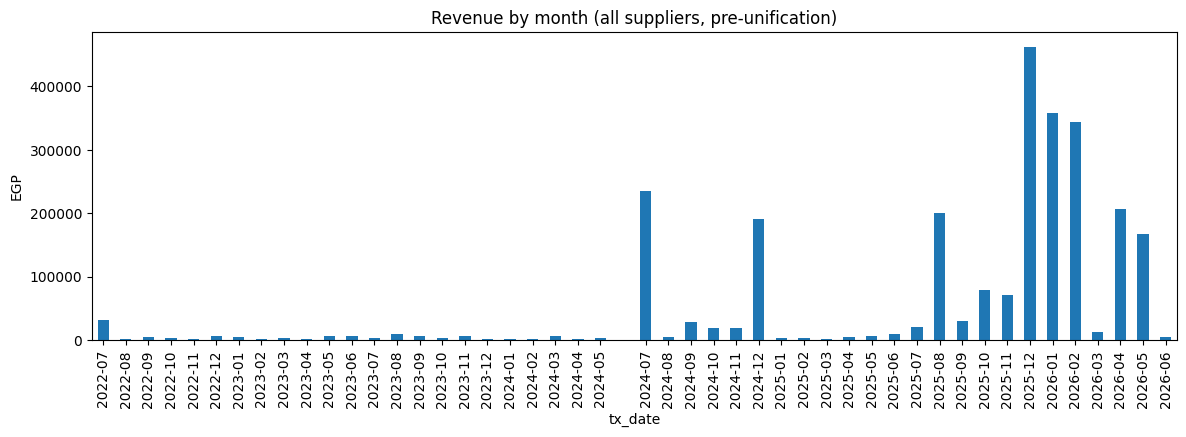

In [6]:
# Distribution snapshot after cleaning
fig_df = clean.groupby(clean['tx_date'].dt.to_period('M')).agg(
    transactions=('id','count'), revenue=('total_amount','sum'))
ax = fig_df['revenue'].plot(kind='bar', figsize=(14,4), title='Revenue by month (all suppliers, pre-unification)')
ax.set_ylabel('EGP');

> Note the spikes (2024-12, 2025-08) are **export-window artifacts** of suppliers 60 and 69, not real seasonality — exactly why per-supplier analysis comes before unified analysis.

## 4. Outputs

In [7]:
clean.to_csv('clean_sales.csv', index=False)
quarantine.to_csv('quarantine_rows.csv', index=False)

with open('qa_report.md', 'w', encoding='utf-8') as f:
    f.write('# Data Quality Report — Notebook 1\n\n')
    f.write(f'- Raw rows: **{n0:,}** -> Clean rows: **{len(clean):,}** (quarantined: {len(quarantine)})\n')
    f.write(f'- Columns: 20 -> {clean.shape[1]} (dropped 4 geo + created_at + creation_date raw; added tx_date, rep fields, outlier flag)\n\n')
    f.write('## Cleaning ledger\n\n' + qa.to_markdown(index=False) + '\n\n')
    f.write('## Per-supplier coverage\n\n' + coverage.to_markdown() + '\n')

print('Wrote: clean_sales.csv, quarantine_rows.csv, qa_report.md')
print(f'Final shape: {clean.shape}')

Wrote: clean_sales.csv, quarantine_rows.csv, qa_report.md
Final shape: (9989, 18)


---
**Next:** Notebook 2 — Entity Resolution (normalization → attribute extraction → char n-gram candidate generation → pairwise classifier → constrained clustering → HITL tiers).